
# Direct MLR benchmark: 2–7-year blocked cross-validation

This notebook repeats the same raw-input centered 3-month PP verification for held-out block widths of **2, 3, 4, 5, 6, and 7 years**, but replaces the CS-White LIM with a direct multiple linear regression benchmark.

Important comparison rule:

- Every month belonging to a held-out block is eligible as a forecast initialization.
- The LIM operator is fitted without any data from that initialization block.
- Forecast targets may extend beyond the held-out block. This is necessary to compare the full 1–23-month lead range for a 2-year exclusion window.
- Therefore, “out-of-sample” here refers strictly to the **initialization period and operator fitting**, matching the leave-\(n\)-year sensitivity logic. It is less strict than requiring the full forecast target window to remain inside the held-out block.

Outputs:

1. One netCDF file for each exclusion window.
2. A 2×3 heatmap panel, one panel per window.
3. Regional skill curves with one line per window.
4. Six separate latest-skillful-lead maps, one per window.


In [1]:

# ============================================================
# 0. Imports and settings
# ============================================================

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
# scipy is not required for the direct MLR benchmark.

from pathlib import Path
from datetime import date
from matplotlib.colors import BoundaryNorm, ListedColormap


STATE_FILE = Path(
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/"
    "Cyclostationary_LIM_ORAS5_XRO10_GlobColour_"
    "PP_RECCAP2_all_regions_valid_zero30_1998_2025.nc"
)

OUT_DIR = Path(
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

VALID_MASK_FILE = Path(
    "/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/"
    "GlobColour_PP_grid_validity_RECCAP2_all_regions/"
    "valid_mask_zero30/"
    "RECCAP2_all_regions_valid_mask_zero30_on_PPgrid.nc"
)

# Compare exclusion-window lengths.
WINDOW_YEARS = np.arange(2, 8, dtype=int)

MAX_LEAD = 23
INTERNAL_MAX_LEAD = MAX_LEAD + 1
THRESHOLD = 0.5
TARGET_STATE = "PP"
FIT_MAX_LAG_MONTHS = INTERNAL_MAX_LEAD

APPLY_COVARIANCE_PHASE_SMOOTHING = False
PHASE_AVERAGING_FOURIER_MODES = None
A_FOURIER_MODES = 2

COVARIANCE_RIDGE = 0.0
PINV_RCOND = 1.0e-10
MIN_PHASE_SAMPLES = 12

# Direct MLR settings.
# None means use all current states: PP(t) + XRO10(t).
PREDICTOR_STATES = None
# Example driver-only version:
# PREDICTOR_STATES = ["TENSO", "WWV", "NPMM", "SPMM", "IOB", "IOD", "SIOD", "TNA", "ATL3", "SASD"]

# Ridge alpha = 0.0 gives ordinary least squares.
# Monthly samples are short, so a small ridge is safer.
RIDGE_ALPHA = 1.0e-3
MIN_MLR_SAMPLES = 8

# How to exclude training pairs that touch the validation period.
# endpoint: require both X(t) and PP(t+lead) outside the validation block.
# full_path: require every month from t to t+lead outside the validation block.
# init_only: require only X(t) outside the validation block.
TRAINING_SAMPLE_RULE = "endpoint"

# Required for a fair 2–7-year comparison through lead 23:
# only initialization months must belong to the held-out block.
STRICT_WITHIN_VALIDATION_BLOCK = False

EXCLUDE_REGIONS = [6, 18, 19, 29]
SAVE_FIGURES = False

CENTRAL_LONGITUDE = 210
PLOT_STRIDE = 4
DISPLAY_MAX_LEAD = 15

FIG_HEATMAP_WINDOWS = OUT_DIR / (
    "Direct_MLR_PP_leave2to7yearblockout_23month_"
    "pooled_skill_heatmaps.png"
)
FIG_LINES_WINDOWS = OUT_DIR / (
    "Direct_MLR_PP_leave2to7yearblockout_23month_"
    "regional_skill_lines.png"
)

BASIN_SHORT = {
    "Pacific Ocean": "PO",
    "Indian Ocean": "IO",
    "Atlantic Ocean": "AO",
    "Southern Ocean": "SO",
    "Arctic Ocean": "ArO",
}

BASIN_ORDER = [
    "Pacific Ocean",
    "Indian Ocean",
    "Atlantic Ocean",
    "Southern Ocean",
    "Arctic Ocean",
]



def skill_file_for_window(window_years):
    return OUT_DIR / (
        "Direct_MLR_PP_forecast_skill_23month_"
        f"3month_running_mean_leave{window_years}yearblockout_"
        "corr_threshold05_RECCAP2_all_regions_valid_zero30.nc"
    )


def map_file_for_window(window_years):
    return OUT_DIR / (
        "Map_latest_PP_skillful_lead_Direct_MLR_"
        f"leave{window_years}yearblockout_23month_"
        "3month_running_mean_corr_ge_05_"
        "RECCAP2_all_regions_valid_zero30_"
        "excluding_R6_R18_R19_R29.png"
    )


In [2]:
# ============================================================
# 1. Helpers
# ============================================================

def decode_strings(values):
    return np.asarray([
        v.decode("utf-8") if isinstance(v, bytes) else str(v)
        for v in values
    ], dtype=object)


def decode_str(v):
    if isinstance(v, bytes):
        return v.decode("utf-8")
    arr = np.asarray(v)
    if arr.shape == ():
        item = arr.item()
        return item.decode("utf-8") if isinstance(item, bytes) else str(item)
    return str(v)


def corr_1d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    ok = np.isfinite(a) & np.isfinite(b)
    if ok.sum() < 3:
        return np.nan
    a = a[ok]
    b = b[ok]
    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


def latest_skill_month(skill, threshold=0.5):
    skill = np.asarray(skill, dtype=float)
    good = np.where(np.isfinite(skill) & (skill >= threshold))[0]
    return 0 if good.size == 0 else int(good.max() + 1)


def build_year_blocks(times, block_years=7):
    years = pd.DatetimeIndex(pd.to_datetime(times)).year.values
    unique_years = np.unique(years)
    blocks = []

    for i0 in range(0, len(unique_years), block_years):
        fold_years = unique_years[i0:i0 + block_years]
        blocks.append({
            "fold": len(blocks),
            "years": fold_years.astype(np.int16),
            "start_year": int(fold_years[0]),
            "end_year": int(fold_years[-1]),
            "validation_mask": np.isin(years, fold_years),
        })

    return blocks


def periodic_fourier_truncate(x, max_mode=2, axis=0):
    """
    Retain the annual mean and Fourier harmonics 1...max_mode
    along a 12-phase periodic axis.

    This is the explicit Python substitute used here for the phase
    smoothing / Fourier-mode truncation called by the MATLAB workflow.
    """
    x = np.asarray(x, dtype=np.float64)

    if max_mode is None:
        return x.copy()

    nphase = x.shape[axis]
    if nphase != 12:
        raise ValueError(
            f"Expected 12 phases along axis {axis}; found {nphase}."
        )

    coeff = np.fft.fft(x, axis=axis)
    keep = np.zeros(nphase, dtype=bool)
    keep[0] = True

    max_mode = int(min(max_mode, nphase // 2))
    for k in range(1, max_mode + 1):
        keep[k] = True
        keep[-k] = True

    shape = [1] * x.ndim
    shape[axis] = nphase
    coeff = coeff * keep.reshape(shape)

    return np.fft.ifft(coeff, axis=axis).real


def compute_cs_observed_correlation(
    X,
    months,
    training_time_mask,
    maxlag=6,
    min_samples=12,
):
    """
    MATLAB-style CorrFcn_CS_Obs equivalent for held-out fitting.

    K[phase, lag] = mean{x(t+lag) x(t)^T}, with phase defined by
    the calendar month of x(t). A lagged pair is admitted only when
    the full monthly path t...t+lag belongs to the training data.

    X is already a standardized anomaly state vector, so no monthly
    intercept is fitted or added.
    """
    X = np.asarray(X, dtype=np.float64)
    months = np.asarray(months, dtype=np.int16)
    training_time_mask = np.asarray(training_time_mask, dtype=bool)

    n_time, n_state = X.shape

    K = np.full(
        (12, maxlag + 1, n_state, n_state),
        np.nan,
        dtype=np.float64,
    )
    n_samples = np.zeros(
        (12, maxlag + 1),
        dtype=np.int16,
    )

    for phase in range(1, 13):
        for lag in range(maxlag + 1):
            candidate = np.where(
                months[:n_time - lag] == phase
            )[0]

            accepted = []

            for it in candidate:
                # Prevent a covariance sample from crossing through the
                # held-out validation block.
                if not np.all(training_time_mask[it:it + lag + 1]):
                    continue

                x0 = X[it]
                x1 = X[it + lag]

                if np.isfinite(x0).all() and np.isfinite(x1).all():
                    accepted.append(it)

            n = len(accepted)
            n_samples[phase - 1, lag] = n

            if n < min_samples:
                continue

            idx = np.asarray(accepted, dtype=int)
            X0 = X[idx, :]
            X1 = X[idx + lag, :]

            # Orientation follows y = G x0:
            # K(lag) = E[x(t+lag) x(t)^T].
            K[phase - 1, lag] = (
                X1.T @ X0
            ) / n

    return K, n_samples


def _stabilize_discrete_operator(
    G,
    max_modulus=0.999,
    eigenvalue_eps=1.0e-12,
):
    """
    Spectrally stabilize a real-valued discrete propagator.

    Eigenvalue phases are retained. Only eigenvalues whose modulus exceeds
    max_modulus are radially clipped. The reconstructed real part is returned
    when the imaginary residual is numerical noise.
    """
    G = np.asarray(G, dtype=float)

    if max_modulus is None:
        return G.copy(), False, np.nan

    eigvals, eigvecs = np.linalg.eig(G)
    mod = np.abs(eigvals)
    max_before = float(np.nanmax(mod))

    scale = np.ones_like(mod, dtype=float)
    unstable = mod > max_modulus
    scale[unstable] = max_modulus / np.maximum(
        mod[unstable],
        eigenvalue_eps,
    )

    eigvals_stable = eigvals * scale

    try:
        G_stable = (
            eigvecs
            @ np.diag(eigvals_stable)
            @ np.linalg.inv(eigvecs)
        )
    except np.linalg.LinAlgError:
        # Fall back to SVD norm clipping if the eigenvector matrix is singular.
        U, s, Vt = np.linalg.svd(G, full_matrices=False)
        s = np.minimum(s, max_modulus)
        G_stable = U @ np.diag(s) @ Vt

    G_stable = np.real_if_close(G_stable, tol=1000)
    G_stable = np.asarray(np.real(G_stable), dtype=float)

    return G_stable, bool(np.any(unstable)), max_before


def fit_matlab_style_cs_white(
    X,
    months,
    training_time_mask,
    dt=1.0 / 12.0,
    maxlag=6,
    phase_average_modes=None,
    apply_covariance_phase_smoothing=False,
    a_fourier_modes=2,
    covariance_ridge=0.0,
    pinv_rcond=1.0e-10,
    min_samples=12,
    max_one_month_eigenvalue_modulus=0.999,
    eigenvalue_eps=1.0e-12,
):
    """
    Stable cyclostationary white-noise LIM.

    Main forecast operator:
        G_m = K_m(1) @ pinv(K_m(0))

    This is the discrete one-month operator and is equivalent to direct
    monthly multivariate regression. It avoids the unstable inversion of N1
    required by the finite-difference N2 @ pinv(N1) estimate.

    The N0/N1/N2 matrices and both continuous-time drift estimates are still
    saved as diagnostics.
    """
    K_raw, n_samples = compute_cs_observed_correlation(
        X=X,
        months=months,
        training_time_mask=training_time_mask,
        maxlag=maxlag,
        min_samples=min_samples,
    )

    if np.isnan(K_raw[:, :3]).any():
        raise ValueError(
            "At least one phase lacks enough lag-0/1/2 covariance samples."
        )

    if apply_covariance_phase_smoothing:
        if phase_average_modes is None:
            raise ValueError(
                "phase_average_modes must be set when covariance smoothing is enabled."
            )
        K_used = periodic_fourier_truncate(
            K_raw,
            max_mode=phase_average_modes,
            axis=0,
        )
    else:
        K_used = K_raw.copy()

    N0 = K_used[:, 0]
    N1 = (K_used[:, 1] - K_used[:, 0]) / dt
    N2 = (
        K_used[:, 0]
        - 2.0 * K_used[:, 1]
        + K_used[:, 2]
    ) / (dt ** 2)

    n_phase, n_state, _ = N0.shape

    G_one_month_raw = np.full_like(N0, np.nan)
    G_one_month = np.full_like(N0, np.nan)
    A_first_derivative_diagnostic = np.full_like(N0, np.nan)
    A_second_derivative_diagnostic = np.full_like(N0, np.nan)

    was_stabilized = np.zeros(12, dtype=bool)
    max_eig_before = np.full(12, np.nan)

    for iphase in range(n_phase):
        C0 = N0[iphase].copy()
        D1 = N1[iphase].copy()

        if covariance_ridge > 0:
            scale_c0 = np.trace(C0) / n_state
            if not np.isfinite(scale_c0) or scale_c0 <= 0:
                scale_c0 = 1.0
            C0 = (
                C0
                + covariance_ridge
                * scale_c0
                * np.eye(n_state)
            )

            scale_d1 = np.linalg.norm(D1, ord="fro") / max(n_state, 1)
            if not np.isfinite(scale_d1) or scale_d1 <= 0:
                scale_d1 = 1.0
            D1 = (
                D1
                + covariance_ridge
                * scale_d1
                * np.eye(n_state)
            )

        G_raw = (
            K_used[iphase, 1]
            @ np.linalg.pinv(
                C0,
                rcond=pinv_rcond,
            )
        )

        G_stable, clipped, max_before = _stabilize_discrete_operator(
            G_raw,
            max_modulus=max_one_month_eigenvalue_modulus,
            eigenvalue_eps=eigenvalue_eps,
        )

        G_one_month_raw[iphase] = G_raw
        G_one_month[iphase] = G_stable
        was_stabilized[iphase] = clipped
        max_eig_before[iphase] = max_before

        A_first_derivative_diagnostic[iphase] = (
            N1[iphase]
            @ np.linalg.pinv(
                C0,
                rcond=pinv_rcond,
            )
        )

        try:
            A_second_derivative_diagnostic[iphase] = (
                N2[iphase]
                @ np.linalg.pinv(
                    D1,
                    rcond=pinv_rcond,
                )
            )
        except np.linalg.LinAlgError:
            A_second_derivative_diagnostic[iphase] = np.nan

    # Continuous-time A is diagnostic only. Forecasts use G_one_month directly.
    A = np.full_like(G_one_month, np.nan)
    for iphase in range(12):
        try:
            A_complex = logm(G_one_month[iphase]) / dt
            A[iphase] = np.real_if_close(
                A_complex,
                tol=1000,
            ).real
        except Exception:
            A[iphase] = np.nan

    # Safe monodromy diagnostic.
    monodromy = np.eye(n_state)
    monodromy_is_finite = True

    for iphase in range(12):
        monodromy = G_one_month[iphase] @ monodromy
        if not np.isfinite(monodromy).all():
            monodromy_is_finite = False
            break

    if monodromy_is_finite:
        try:
            max_floquet_modulus = float(
                np.max(
                    np.abs(
                        np.linalg.eigvals(monodromy)
                    )
                )
            )
        except np.linalg.LinAlgError:
            max_floquet_modulus = np.nan
    else:
        max_floquet_modulus = np.nan

    return {
        "K_raw": K_raw,
        "K_used": K_used,
        "N0": N0,
        "N1": N1,
        "N2": N2,
        "A": A,
        "A_first_derivative_diagnostic": A_first_derivative_diagnostic,
        "A_second_derivative_diagnostic": A_second_derivative_diagnostic,
        "G_one_month_raw": G_one_month_raw,
        "G_one_month": G_one_month,
        "n_samples": n_samples,
        "was_stabilized": was_stabilized,
        "max_one_month_eigenvalue_modulus_before": max_eig_before,
        "max_floquet_modulus": max_floquet_modulus,
    }

def cs_white_evolution_operators(
    G_one_month,
    max_lead,
):
    """
    Ordered cyclostationary evolution operators.

    output[start_phase, lead] maps x(t) to x(t+lead).
    Lead zero is the identity.
    """
    G_one_month = np.asarray(
        G_one_month,
        dtype=np.float64,
    )

    n_state = G_one_month.shape[-1]

    evolution = np.full(
        (12, max_lead + 1, n_state, n_state),
        np.nan,
        dtype=np.float64,
    )

    for start_phase in range(12):
        current = np.eye(n_state)
        evolution[start_phase, 0] = current

        for lead in range(1, max_lead + 1):
            step_phase = (
                start_phase + lead - 1
            ) % 12

            current = (
                G_one_month[step_phase]
                @ current
            )

            evolution[start_phase, lead] = current

    return evolution


def forecast_matlab_style_cs_white(
    X,
    months,
    init_indices,
    evolution,
    max_lead,
):
    """
    Deterministic MATLAB-style forecast:
        y = G_CS_White(start_phase, lead) @ x0

    No fitted intercept or fold-specific mean is added.
    """
    X = np.asarray(X, dtype=np.float64)
    init_indices = np.asarray(init_indices, dtype=int)

    n_state = X.shape[1]

    Xhat = np.full(
        (
            len(init_indices),
            max_lead + 1,
            n_state,
        ),
        np.nan,
        dtype=np.float64,
    )

    for j, it in enumerate(init_indices):
        x0 = X[it].copy()

        if not np.isfinite(x0).all():
            continue

        start_phase = int(months[it] - 1)

        for lead in range(max_lead + 1):
            G = evolution[start_phase, lead]

            if np.isfinite(G).all():
                Xhat[j, lead] = G @ x0

    return Xhat




def centered_mean_3_timeseries(x):
    """At t, mean of t-1, t, t+1; strict NaN handling."""
    x = np.asarray(x, dtype=np.float64)
    out = np.full(x.shape, np.nan, dtype=np.float64)
    if x.size < 3:
        return out
    window = np.stack([x[:-2], x[1:-1], x[2:]], axis=1)
    good = np.isfinite(window).all(axis=1)
    out[np.where(good)[0] + 1] = window[good].mean(axis=1)
    return out


def centered_mean_3_forecast(pp_raw, max_lead):
    """Nominal lead L averages raw forecast leads L-1, L, L+1."""
    pp_raw = np.asarray(pp_raw, dtype=np.float64)
    if pp_raw.ndim != 2 or pp_raw.shape[1] < max_lead + 2:
        raise ValueError(
            f"Forecast must include lead 0 through {max_lead + 1}; "
            f"received {pp_raw.shape}."
        )

    out = np.full((pp_raw.shape[0], max_lead), np.nan, dtype=np.float64)
    for lead in range(1, max_lead + 1):
        window = pp_raw[:, lead - 1:lead + 2]
        good = np.isfinite(window).all(axis=1)
        out[good, lead - 1] = window[good].mean(axis=1)
    return out


def get_region_label(ds, reg, short=True):
    reg = int(reg)
    try:
        name = decode_str(ds["region_name"].sel(region=reg).values)
    except Exception:
        name = f"region {reg}"
    try:
        basin = decode_str(ds["basin"].sel(region=reg).values)
    except Exception:
        basin = ""
    try:
        original_id = int(ds["original_region_id"].sel(region=reg).values)
    except Exception:
        original_id = -999

    if short:
        return f"R{reg}. {name}"
    if basin and original_id > 0:
        return f"R{reg}. {basin}:{original_id} {name}"
    return f"R{reg}. {name}"


def get_basin_name(ds, reg):
    try:
        raw = decode_str(ds["basin"].sel(region=int(reg)).values).strip()
    except Exception:
        return "Unknown"
    name = raw.lower()
    if "pacific" in name:
        return "Pacific Ocean"
    if "indian" in name:
        return "Indian Ocean"
    if "atlantic" in name:
        return "Atlantic Ocean"
    if "southern" in name:
        return "Southern Ocean"
    if "arctic" in name:
        return "Arctic Ocean"
    return raw


def lon_to_180(lon):
    return ((lon + 180.0) % 360.0) - 180.0


def weighted_centroid(lon, lat, mask):
    lon2d, lat2d = np.meshgrid(lon, lat)
    weights = np.where(mask, np.cos(np.deg2rad(lat2d)), 0.0)
    wsum = np.nansum(weights)
    if wsum <= 0:
        return np.nan, np.nan
    lon_rad = np.deg2rad(lon2d)
    x = np.nansum(weights * np.cos(lon_rad)) / wsum
    y = np.nansum(weights * np.sin(lon_rad)) / wsum
    lon_c = np.rad2deg(np.arctan2(y, x)) % 360.0
    lat_c = np.nansum(weights * lat2d) / wsum
    return lon_c, lat_c


def add_cyclic_manual(data, lon):
    lon = np.asarray(lon, dtype=np.float64)
    sort_idx = np.argsort(lon)
    lon_sorted = lon[sort_idx]
    data_sorted = data[:, sort_idx]
    dlon = float(np.nanmedian(np.diff(lon_sorted)))
    lon_cyc = np.concatenate([lon_sorted, [lon_sorted[-1] + dlon]])
    data_cyc = np.concatenate([data_sorted, data_sorted[:, :1]], axis=1)
    return data_cyc, lon_cyc


def fit_direct_mlr(X_train, y_train, ridge_alpha=0.0, min_samples=8):
    """
    Fit y = intercept + X @ beta by OLS or ridge.

    The intercept is not regularized.
    """
    X_train = np.asarray(X_train, dtype=np.float64)
    y_train = np.asarray(y_train, dtype=np.float64)

    ok = np.isfinite(y_train) & np.isfinite(X_train).all(axis=1)
    X = X_train[ok]
    y = y_train[ok]

    n_sample, n_predictor = X.shape

    if n_sample < min_samples:
        return None, n_sample

    if ridge_alpha == 0.0 and n_sample <= n_predictor + 1:
        return None, n_sample

    Xd = np.column_stack([np.ones(n_sample), X])

    if ridge_alpha == 0.0:
        coef, *_ = np.linalg.lstsq(Xd, y, rcond=None)
    else:
        penalty = np.eye(n_predictor + 1)
        penalty[0, 0] = 0.0

        lhs = Xd.T @ Xd + ridge_alpha * penalty
        rhs = Xd.T @ y

        try:
            coef = np.linalg.solve(lhs, rhs)
        except np.linalg.LinAlgError:
            coef = np.linalg.lstsq(lhs, rhs, rcond=None)[0]

    return coef, n_sample


def predict_direct_mlr(X, coef):
    """
    Predict yhat = intercept + X @ beta.
    """
    X = np.asarray(X, dtype=np.float64)
    out = np.full(X.shape[0], np.nan, dtype=np.float64)

    if coef is None:
        return out

    ok = np.isfinite(X).all(axis=1)

    if ok.sum() == 0:
        return out

    out[ok] = coef[0] + X[ok] @ coef[1:]
    return out


def training_pair_is_allowed(it, raw_lead, training_mask, rule="endpoint"):
    """
    Decide whether the direct-regression sample X(t), PP(t+lead) can be used.
    """
    if rule == "init_only":
        return bool(training_mask[it])

    if rule == "endpoint":
        return bool(training_mask[it] and training_mask[it + raw_lead])

    if rule == "full_path":
        return bool(np.all(training_mask[it:it + raw_lead + 1]))

    raise ValueError(f"Unknown TRAINING_SAMPLE_RULE: {rule}")


In [3]:

# ============================================================
# 2. Fit and forecast for exclusion windows of 2–7 years
# ============================================================

if not STATE_FILE.exists():
    raise FileNotFoundError(f"State-vector file not found:\n{STATE_FILE}")

with xr.open_dataset(STATE_FILE) as ds:
    ds_lim = ds.load()

if "state_vector" not in ds_lim:
    raise KeyError(f"state_vector not found in:\n{STATE_FILE}")

state_vector = ds_lim["state_vector"].transpose("region", "time", "state")
regions = state_vector.region.values.astype(np.int16)
times = state_vector.time.values
states = decode_strings(state_vector.state.values)
months = pd.DatetimeIndex(pd.to_datetime(times)).month.values.astype(np.int16)

match = np.where(states == TARGET_STATE)[0]
if match.size != 1:
    raise ValueError(f"TARGET_STATE={TARGET_STATE!r} not unique: {list(states)}")
target_idx = int(match[0])

if PREDICTOR_STATES is None:
    predictor_states = list(states)
else:
    predictor_states = list(PREDICTOR_STATES)

predictor_indices = []
for predictor_name in predictor_states:
    predictor_match = np.where(states == predictor_name)[0]
    if predictor_match.size != 1:
        raise ValueError(
            f"Predictor state {predictor_name!r} not unique: {list(states)}"
        )
    predictor_indices.append(int(predictor_match[0]))

predictor_indices = np.asarray(predictor_indices, dtype=int)
coefficient_predictor = np.asarray(
    ["intercept"] + predictor_states,
    dtype=object,
)

n_region = len(regions)
n_time = len(times)
n_predictor = len(predictor_indices)
lead_coord = np.arange(1, MAX_LEAD + 1, dtype=np.int16)
init_month_coord = np.arange(1, 13, dtype=np.int16)

results_by_window = {}


for window_years in WINDOW_YEARS:
    window_years = int(window_years)
    print("\n" + "=" * 72)
    print(f"Leave-{window_years}-year-block-out")
    print("=" * 72)

    folds = build_year_blocks(times, window_years)
    n_fold = len(folds)

    fold_id_for_time = np.full(n_time, -1, dtype=np.int16)
    validation_init_mask = np.zeros(n_time, dtype=bool)

    for fold in folds:
        fold_indices = np.where(fold["validation_mask"])[0]
        fold["init_indices"] = fold_indices

        fold_id_for_time[fold_indices] = fold["fold"]
        validation_init_mask[fold_indices] = True

    if np.any(fold_id_for_time < 0):
        raise RuntimeError(
            f"Some months were not assigned for window={window_years}."
        )

    print("Validation folds:")
    for fold in folds:
        init_dates = pd.DatetimeIndex(
            pd.to_datetime(times[fold["init_indices"]])
        )
        print(
            f"  fold {fold['fold']:02d}: "
            f"{fold['start_year']}–{fold['end_year']}; "
            f"{len(fold['years'])} year(s), "
            f"{len(fold['init_indices'])} initialization months"
        )

    pp_prediction_oos = np.full(
        (n_region, n_time, MAX_LEAD),
        np.nan,
        dtype=np.float32,
    )

    n_training_samples = np.zeros(
        (n_region, n_fold, 12, FIT_MAX_LAG_MONTHS + 1),
        dtype=np.int16,
    )

    mlr_coefficients = np.full(
        (
            n_region,
            n_fold,
            12,
            FIT_MAX_LAG_MONTHS + 1,
            n_predictor + 1,
        ),
        np.nan,
        dtype=np.float32,
    )

    for ir, reg in enumerate(regions):
        print(
            f"[window {window_years}y] "
            f"[{ir + 1:02d}/{n_region:02d}] region {int(reg)}"
        )

        X = (
            state_vector
            .sel(region=reg)
            .values
            .astype(np.float64)
        )
        X_predictor = X[:, predictor_indices]
        pp_raw = X[:, target_idx]

        for fold in folds:
            ifold = fold["fold"]
            validation_mask = fold["validation_mask"]
            training_mask = ~validation_mask
            init_idx_fold = fold["init_indices"]

            pp_raw_prediction_fold = np.full(
                (len(init_idx_fold), INTERNAL_MAX_LEAD + 1),
                np.nan,
                dtype=np.float64,
            )

            # raw lead 0 is the observed initial PP, so that the centered
            # 3-month forecast at nominal lead 1 can use raw leads 0, 1, 2.
            pp_raw_prediction_fold[:, 0] = pp_raw[init_idx_fold]

            for init_month in range(1, 13):
                train_month_mask = months == init_month

                validation_local = np.where(
                    months[init_idx_fold] == init_month
                )[0]

                if validation_local.size == 0:
                    continue

                validation_global = init_idx_fold[validation_local]

                for raw_lead in range(1, INTERNAL_MAX_LEAD + 1):
                    if raw_lead > FIT_MAX_LAG_MONTHS:
                        continue

                    max_init = n_time - raw_lead
                    if max_init <= 0:
                        continue

                    candidate_train = np.where(train_month_mask[:max_init])[0]
                    accepted = []

                    for it in candidate_train:
                        if not training_pair_is_allowed(
                            it,
                            raw_lead,
                            training_mask,
                            rule=TRAINING_SAMPLE_RULE,
                        ):
                            continue

                        if (
                            np.isfinite(X_predictor[it, :]).all()
                            and np.isfinite(pp_raw[it + raw_lead])
                        ):
                            accepted.append(it)

                    if len(accepted) == 0:
                        continue

                    accepted = np.asarray(accepted, dtype=int)

                    coef, n_fit = fit_direct_mlr(
                        X_train=X_predictor[accepted, :],
                        y_train=pp_raw[accepted + raw_lead],
                        ridge_alpha=RIDGE_ALPHA,
                        min_samples=MIN_MLR_SAMPLES,
                    )

                    n_training_samples[
                        ir,
                        ifold,
                        init_month - 1,
                        raw_lead,
                    ] = n_fit

                    if coef is None:
                        continue

                    mlr_coefficients[
                        ir,
                        ifold,
                        init_month - 1,
                        raw_lead,
                        :,
                    ] = coef.astype(np.float32)

                    ok_validation = validation_global + raw_lead < n_time
                    validation_global_lead = validation_global[ok_validation]
                    validation_local_lead = validation_local[ok_validation]

                    if validation_global_lead.size == 0:
                        continue

                    yhat = predict_direct_mlr(
                        X_predictor[validation_global_lead, :],
                        coef,
                    )

                    pp_raw_prediction_fold[
                        validation_local_lead,
                        raw_lead,
                    ] = yhat

            pred_3mon = centered_mean_3_forecast(
                pp_raw_prediction_fold,
                MAX_LEAD,
            )

            for j, it in enumerate(init_idx_fold):
                for lead in range(1, MAX_LEAD + 1):
                    target = it + lead

                    # Need observation at target-1, target, target+1.
                    if target - 1 < 0 or target + 1 >= n_time:
                        continue

                    if STRICT_WITHIN_VALIDATION_BLOCK:
                        required = np.asarray(
                            [it, target - 1, target, target + 1],
                            dtype=int,
                        )
                        if not np.all(
                            fold_id_for_time[required] == ifold
                        ):
                            continue

                    value = pred_3mon[j, lead - 1]
                    if np.isfinite(value):
                        pp_prediction_oos[ir, it, lead - 1] = value

    results_by_window[window_years] = {
        "folds": folds,
        "fold_id_for_time": fold_id_for_time,
        "validation_init_mask": validation_init_mask,
        "pp_prediction_oos": pp_prediction_oos,
        "n_training_samples": n_training_samples,
        "mlr_coefficients": mlr_coefficients,
        "coefficient_predictor": coefficient_predictor,
    }



Leave-2-year-block-out
Validation folds:
  fold 00: 1998–1999; 2 year(s), 24 initialization months
  fold 01: 2000–2001; 2 year(s), 24 initialization months
  fold 02: 2002–2003; 2 year(s), 24 initialization months
  fold 03: 2004–2005; 2 year(s), 24 initialization months
  fold 04: 2006–2007; 2 year(s), 24 initialization months
  fold 05: 2008–2009; 2 year(s), 24 initialization months
  fold 06: 2010–2011; 2 year(s), 24 initialization months
  fold 07: 2012–2013; 2 year(s), 24 initialization months
  fold 08: 2014–2015; 2 year(s), 24 initialization months
  fold 09: 2016–2017; 2 year(s), 24 initialization months
  fold 10: 2018–2019; 2 year(s), 24 initialization months
  fold 11: 2020–2021; 2 year(s), 24 initialization months
  fold 12: 2022–2023; 2 year(s), 24 initialization months
  fold 13: 2024–2025; 2 year(s), 24 initialization months
[window 2y] [01/21] region 1
[window 2y] [02/21] region 2
[window 2y] [03/21] region 3
[window 2y] [04/21] region 4
[window 2y] [05/21] region 5
[

In [4]:

# ============================================================
# 3. Calculate skill and save one netCDF file per window
# ============================================================

region_name_values = (
    decode_strings(ds_lim["region_name"].sel(region=regions).values)
    if "region_name" in ds_lim
    else np.asarray([f"region {int(r)}" for r in regions], dtype=object)
)
basin_values = (
    decode_strings(ds_lim["basin"].sel(region=regions).values)
    if "basin" in ds_lim
    else np.asarray([""] * n_region, dtype=object)
)
original_region_id_values = (
    ds_lim["original_region_id"].sel(region=regions).values.astype(np.int16)
    if "original_region_id" in ds_lim
    else np.full(n_region, -999, dtype=np.int16)
)

skill_datasets = {}


for window_years in WINDOW_YEARS:
    window_years = int(window_years)
    result = results_by_window[window_years]

    folds = result["folds"]
    n_fold = len(folds)
    fold_id_for_time = result["fold_id_for_time"]
    validation_init_mask = result["validation_init_mask"]
    pp_prediction_oos = result["pp_prediction_oos"]

    pp_corr = np.full((n_region, MAX_LEAD), np.nan, dtype=np.float64)
    n_pairs = np.zeros((n_region, MAX_LEAD), dtype=np.int16)
    pp_corr_by_init_month = np.full(
        (n_region, 12, MAX_LEAD),
        np.nan,
    )
    n_pairs_by_init_month = np.zeros(
        (n_region, 12, MAX_LEAD),
        dtype=np.int16,
    )
    pp_corr_by_fold = np.full(
        (n_region, n_fold, MAX_LEAD),
        np.nan,
    )
    n_pairs_by_fold = np.zeros(
        (n_region, n_fold, MAX_LEAD),
        dtype=np.int16,
    )

    common_init_idx = np.where(validation_init_mask)[0]

    for ir, reg in enumerate(regions):
        X = state_vector.sel(region=reg).values.astype(np.float64)
        obs_3mon = centered_mean_3_timeseries(X[:, target_idx])

        for lead in range(1, MAX_LEAD + 1):
            init_idx = common_init_idx
            target = init_idx + lead

            valid_target = target + 1 < n_time
            init_idx = init_idx[valid_target]
            target = target[valid_target]

            pred = pp_prediction_oos[ir, init_idx, lead - 1]
            obs = obs_3mon[target]

            ok = np.isfinite(pred) & np.isfinite(obs)
            n_pairs[ir, lead - 1] = int(ok.sum())
            pp_corr[ir, lead - 1] = corr_1d(pred, obs)

            for init_month in range(1, 13):
                choose = months[init_idx] == init_month
                pred_m = pred[choose]
                obs_m = obs[choose]
                ok_m = np.isfinite(pred_m) & np.isfinite(obs_m)
                n_pairs_by_init_month[
                    ir, init_month - 1, lead - 1
                ] = int(ok_m.sum())
                pp_corr_by_init_month[
                    ir, init_month - 1, lead - 1
                ] = corr_1d(pred_m, obs_m)

            for ifold in range(n_fold):
                choose = fold_id_for_time[init_idx] == ifold
                pred_f = pred[choose]
                obs_f = obs[choose]
                ok_f = np.isfinite(pred_f) & np.isfinite(obs_f)
                n_pairs_by_fold[
                    ir, ifold, lead - 1
                ] = int(ok_f.sum())
                pp_corr_by_fold[
                    ir, ifold, lead - 1
                ] = corr_1d(pred_f, obs_f)

    latest_lead = np.array(
        [
            latest_skill_month(pp_corr[ir], THRESHOLD)
            for ir in range(n_region)
        ],
        dtype=np.int16,
    )

    latest_by_month = np.zeros((n_region, 12), dtype=np.int16)
    for ir in range(n_region):
        for im in range(12):
            latest_by_month[ir, im] = latest_skill_month(
                pp_corr_by_init_month[ir, im],
                THRESHOLD,
            )

    fold_start_year = np.array(
        [f["start_year"] for f in folds],
        dtype=np.int16,
    )
    fold_end_year = np.array(
        [f["end_year"] for f in folds],
        dtype=np.int16,
    )
    fold_n_years = np.array(
        [len(f["years"]) for f in folds],
        dtype=np.int16,
    )
    fold_n_months = np.array(
        [f["validation_mask"].sum() for f in folds],
        dtype=np.int16,
    )

    ds_cv = xr.Dataset(
        data_vars={
            "PP_prediction": (
                ("region", "init_time", "lead"),
                pp_prediction_oos,
                {
                    "long_name": (
                        "Cross-validated centered 3-month PP prediction"
                    ),
                    "description": (
                        "Nominal lead L averages raw leads L-1, L, and L+1."
                    ),
                    "units": "standard deviation",
                },
            ),
            "PP_correlation_skill": (
                ("region", "lead"),
                pp_corr.astype(np.float32),
                {
                    "long_name": (
                        f"Leave-{window_years}-year-block-out "
                        "centered 3-month PP correlation skill"
                    )
                },
            ),
            "PP_correlation_skill_by_init_month": (
                ("region", "init_month", "lead"),
                pp_corr_by_init_month.astype(np.float32),
            ),
            "PP_correlation_skill_by_fold": (
                ("region", "validation_fold", "lead"),
                pp_corr_by_fold.astype(np.float32),
            ),
            "n_pairs": (("region", "lead"), n_pairs),
            "n_pairs_by_init_month": (
                ("region", "init_month", "lead"),
                n_pairs_by_init_month,
            ),
            "n_pairs_by_fold": (
                ("region", "validation_fold", "lead"),
                n_pairs_by_fold,
            ),
            "n_training_samples": (
                ("region", "validation_fold", "month", "fit_lag"),
                result["n_training_samples"],
            ),
            "MLR_coefficients": (
                (
                    "region",
                    "validation_fold",
                    "month",
                    "fit_lag",
                    "coefficient_predictor",
                ),
                result["mlr_coefficients"],
                {
                    "description": (
                        "PP(t+fit_lag) = intercept + sum beta_i * predictor_i(t)."
                    ),
                },
            ),
            "latest_lead_corr_ge_05": (
                ("region",),
                latest_lead,
                {"units": "month"},
            ),
            "latest_lead_corr_ge_05_by_init_month": (
                ("region", "init_month"),
                latest_by_month,
            ),
            "validation_fold_for_time": (
                ("init_time",),
                fold_id_for_time,
            ),
            "used_as_validation_initialization": (
                ("init_time",),
                validation_init_mask.astype(np.int8),
            ),
            "fold_start_year": (
                ("validation_fold",),
                fold_start_year,
            ),
            "fold_end_year": (
                ("validation_fold",),
                fold_end_year,
            ),
            "fold_n_years": (
                ("validation_fold",),
                fold_n_years,
            ),
            "fold_n_months": (
                ("validation_fold",),
                fold_n_months,
            ),
            "region_name": (
                ("region",),
                region_name_values.astype(object),
            ),
            "basin": (
                ("region",),
                basin_values.astype(object),
            ),
            "original_region_id": (
                ("region",),
                original_region_id_values,
            ),
        },
        coords={
            "region": regions,
            "init_time": times,
            "lead": lead_coord,
            "init_month": init_month_coord,
            "validation_fold": np.arange(
                n_fold,
                dtype=np.int16,
            ),
            "month": np.arange(1, 13, dtype=np.int16),
            "fit_lag": np.arange(
                FIT_MAX_LAG_MONTHS + 1,
                dtype=np.int16,
            ),
            "coefficient_predictor": result["coefficient_predictor"],
        },
        attrs={
            "title": (
                "Direct MLR blocked cross-validated "
                "centered 3-month PP skill"
            ),
            "state_vector_source_file": str(STATE_FILE),
            "excluded_window_years": window_years,
            "cross_validation": (
                f"Consecutive non-overlapping leave-{window_years}-year "
                "blocks; every held-out month is used as an initialization."
            ),
            "strict_within_validation_block": str(
                STRICT_WITHIN_VALIDATION_BLOCK
            ),
            "verification_rule": (
                "The initialization month is excluded from fitting. "
                "Forecast targets may extend beyond the held-out block, "
                "allowing all windows to be compared through lead 23."
            ),
            "mlr_model": (
                "Direct MLR fitted separately by region, validation fold, "
                "initialization month, and raw lead."
            ),
            "predictor_states": ", ".join(result["coefficient_predictor"][1:]),
            "ridge_alpha": RIDGE_ALPHA,
            "minimum_mlr_samples": MIN_MLR_SAMPLES,
            "training_sample_rule": TRAINING_SAMPLE_RULE,
            "running_mean_alignment": "centered",
            "running_mean_months": 3,
            "max_nominal_lead_months": MAX_LEAD,
            "correlation_threshold": THRESHOLD,
            "date_created": date.today().isoformat(),
        },
    )

    encoding = {
        name: {
            "dtype": "float32",
            "_FillValue": np.float32(-999),
            "zlib": True,
            "complevel": 4,
        }
        for name in [
            "PP_prediction",
            "PP_correlation_skill",
            "PP_correlation_skill_by_init_month",
            "PP_correlation_skill_by_fold",
            "MLR_coefficients",
        ]
    }

    for name in [
        "n_pairs",
        "n_pairs_by_init_month",
        "n_pairs_by_fold",
        "n_training_samples",
        "latest_lead_corr_ge_05",
        "latest_lead_corr_ge_05_by_init_month",
        "validation_fold_for_time",
        "fold_start_year",
        "fold_end_year",
        "fold_n_years",
        "fold_n_months",
        "original_region_id",
        "region",
        "lead",
        "init_month",
        "validation_fold",
        "month",
        "fit_lag",
    ]:
        encoding[name] = {"dtype": "int16", "_FillValue": None}

    encoding["used_as_validation_initialization"] = {
        "dtype": "int8",
        "_FillValue": None,
    }
    encoding["init_time"] = {
        "dtype": "float64",
        "units": "days since 1900-01-01",
        "calendar": "gregorian",
    }

    output_file = skill_file_for_window(window_years)
    if output_file.exists():
        output_file.unlink()

    ds_cv.to_netcdf(
        output_file,
        encoding=encoding,
        engine="netcdf4",
    )
    skill_datasets[window_years] = ds_cv

    print(f"Saved window={window_years}: {output_file}")


Saved window=2: /nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill/Direct_MLR_PP_forecast_skill_23month_3month_running_mean_leave2yearblockout_corr_threshold05_RECCAP2_all_regions_valid_zero30.nc
Saved window=3: /nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill/Direct_MLR_PP_forecast_skill_23month_3month_running_mean_leave3yearblockout_corr_threshold05_RECCAP2_all_regions_valid_zero30.nc
Saved window=4: /nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill/Direct_MLR_PP_forecast_skill_23month_3month_running_mean_leave4yearblockout_corr_threshold05_RECCAP2_all_regions_valid_zero30.nc
Saved window=5: /nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill/Direct_MLR_PP_forecast_skill_23month_3month_running_mean_leave5yearblockout_corr_threshold05_RECCAP2_all_regions_valid_zero30.nc
Saved window=6: /nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill/Direct_MLR_PP_forecast_skill_23month_3month_running_mean_leave6yearblockout_corr_threshold05_RECCAP2_all_regions_v

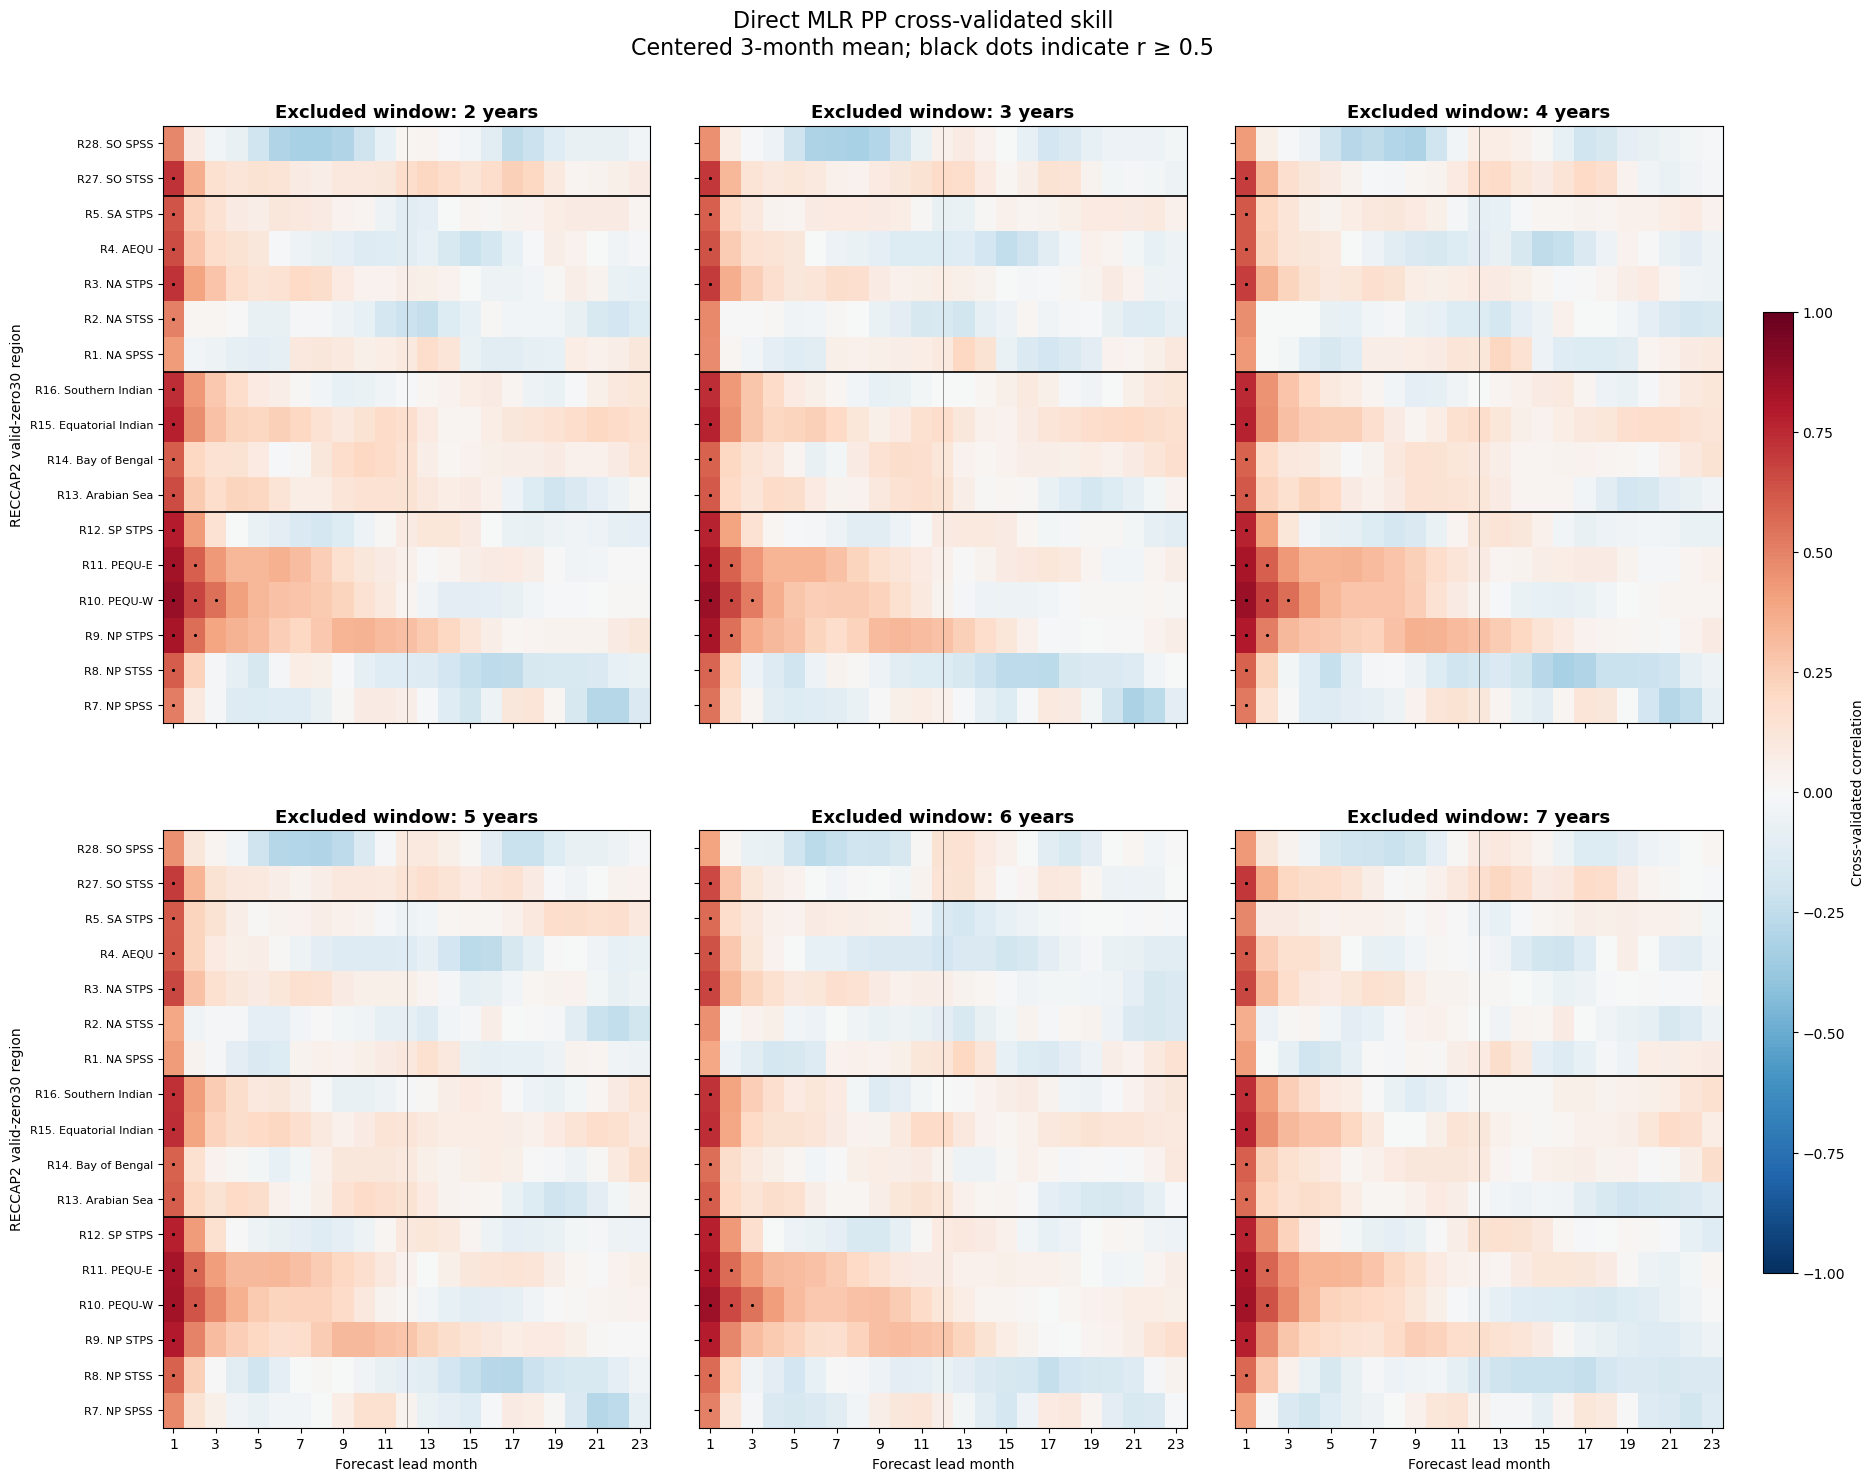

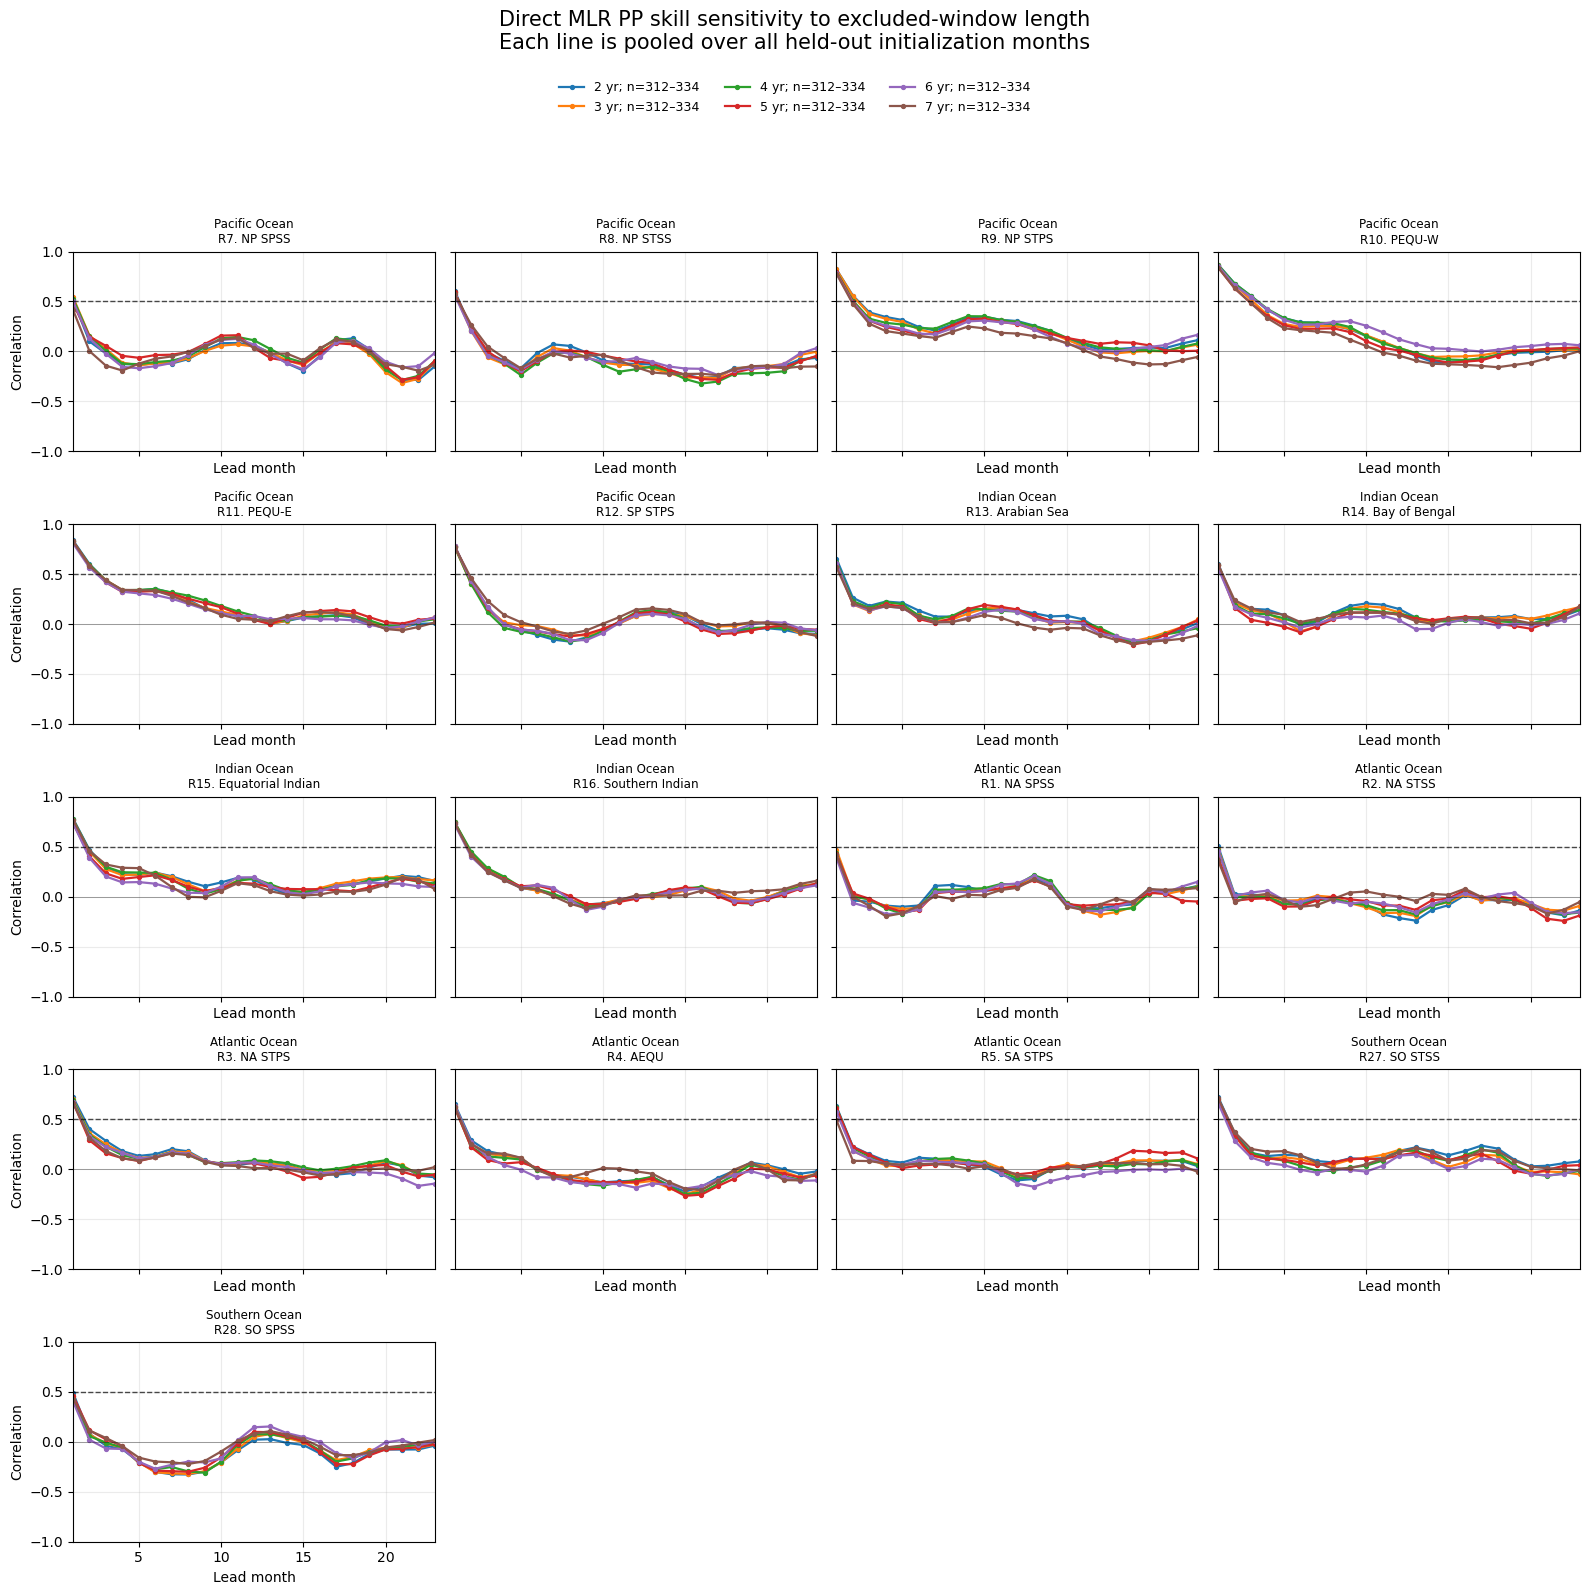

In [5]:

# ============================================================
# 4. Heatmap panels and regional lines distinguished by window
# ============================================================

# Load from disk if this plotting cell is run independently.
if "skill_datasets" not in globals() or not skill_datasets:
    skill_datasets = {}
    for window_years in WINDOW_YEARS:
        window_years = int(window_years)
        with xr.open_dataset(
            skill_file_for_window(window_years)
        ) as ds:
            skill_datasets[window_years] = ds.load()

reference_ds = skill_datasets[int(WINDOW_YEARS[0])]
reference_skill = reference_ds["PP_correlation_skill"]

keep_regions = [
    int(reg)
    for reg in reference_skill.region.values
    if int(reg) not in EXCLUDE_REGIONS
]
region_basin = {
    int(reg): get_basin_name(reference_ds, reg)
    for reg in keep_regions
}
basin_rank = {
    name: i for i, name in enumerate(BASIN_ORDER)
}
regions_plot = np.array(
    sorted(
        keep_regions,
        key=lambda reg: (
            basin_rank.get(
                region_basin[reg],
                len(BASIN_ORDER),
            ),
            reg,
        ),
    ),
    dtype=np.int16,
)
n_region_plot = len(regions_plot)
leads = reference_skill.lead.values.astype(np.int16)

basin_groups = []
for basin_name in BASIN_ORDER:
    idx = [
        i
        for i, reg in enumerate(regions_plot)
        if region_basin[int(reg)] == basin_name
    ]
    if idx:
        basin_groups.append(
            {
                "name": basin_name,
                "start": min(idx),
                "end": max(idx),
            }
        )

# ------------------------------------------------------------
# 4a. One heatmap panel per exclusion window
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    3,
    figsize=(20, 0.50 * n_region_plot + 7.0),
    sharex=True,
    sharey=True,
)
axes = axes.ravel()

last_im = None
for ax, window_years in zip(axes, WINDOW_YEARS):
    window_years = int(window_years)
    r = (
        skill_datasets[window_years]["PP_correlation_skill"]
        .sel(region=regions_plot)
    )

    y_edges = np.arange(n_region_plot + 1)
    x_edges = np.arange(
        leads[0] - 0.5,
        leads[-1] + 1.5,
        1.0,
    )

    last_im = ax.pcolormesh(
        x_edges,
        y_edges,
        r.values,
        vmin=-1,
        vmax=1,
        cmap="RdBu_r",
        shading="auto",
    )

    yy, xx = np.where(
        np.isfinite(r.values) & (r.values >= THRESHOLD)
    )
    ax.plot(
        leads[xx],
        yy + 0.5,
        "k.",
        markersize=2.5,
    )

    for group in basin_groups[:-1]:
        ax.axhline(
            group["end"] + 1,
            color="k",
            lw=1.2,
        )

    if leads[-1] >= 12:
        ax.axvline(
            12,
            color="k",
            lw=0.7,
            alpha=0.4,
        )

    ax.set_title(
        f"Excluded window: {window_years} years",
        fontsize=13,
        fontweight="bold",
    )
    ax.set_xlim(leads[0] - 0.5, leads[-1] + 0.5)
    ax.set_ylim(0, n_region_plot)
    ax.set_xticks(
        np.arange(leads[0], leads[-1] + 1, 2)
    )

for ax in axes[3:]:
    ax.set_xlabel("Forecast lead month")

for ax in axes[::3]:
    ax.set_ylabel("RECCAP2 valid-zero30 region")
    ax.set_yticks(np.arange(n_region_plot) + 0.5)
    ax.set_yticklabels(
        [
            get_region_label(
                reference_ds,
                reg,
                short=True,
            )
            for reg in regions_plot
        ],
        fontsize=8,
    )

fig.suptitle(
    "Direct MLR PP cross-validated skill\n"
    "Centered 3-month mean; black dots indicate r ≥ 0.5",
    fontsize=16,
    y=0.995,
)

fig.subplots_adjust(
    left=0.12,
    right=0.90,
    top=0.92,
    bottom=0.08,
    wspace=0.10,
    hspace=0.18,
)
cax = fig.add_axes([0.92, 0.18, 0.015, 0.62])
cbar = fig.colorbar(last_im, cax=cax)
cbar.set_label("Cross-validated correlation")

if SAVE_FIGURES:
    fig.savefig(
        FIG_HEATMAP_WINDOWS,
        dpi=200,
        bbox_inches="tight",
    )
plt.show()


# ------------------------------------------------------------
# 4b. Regional lines: one pooled-skill line per window
# ------------------------------------------------------------

ncol = 4
nrow = int(np.ceil(n_region_plot / ncol))
fig, axes = plt.subplots(
    nrow,
    ncol,
    figsize=(16, 3.0 * nrow),
    sharex=True,
    sharey=True,
)
axes = np.asarray(axes).ravel()

for ax, reg in zip(axes, regions_plot):
    for window_years in WINDOW_YEARS:
        window_years = int(window_years)
        ds_this = skill_datasets[window_years]
        r = ds_this["PP_correlation_skill"].sel(region=reg)
        n = ds_this["n_pairs"].sel(region=reg)

        finite_n = n.values[np.isfinite(n.values)]
        n_text = (
            f"; n={int(np.nanmin(finite_n))}"
            f"–{int(np.nanmax(finite_n))}"
            if finite_n.size
            else ""
        )

        ax.plot(
            leads,
            r.values,
            marker="o",
            ms=2.8,
            lw=1.6,
            label=f"{window_years} yr{n_text}",
        )

    ax.axhline(
        THRESHOLD,
        color="k",
        lw=1.0,
        ls="--",
        alpha=0.7,
    )
    ax.axhline(0, color="k", lw=0.6, alpha=0.4)
    ax.set_title(
        f"{region_basin[int(reg)]}\n"
        f"{get_region_label(reference_ds, reg, short=True)}",
        fontsize=8.5,
    )
    ax.set_xlim(leads[0], leads[-1])
    ax.set_ylim(-1, 1)
    ax.grid(alpha=0.25)

for ax in axes[n_region_plot:]:
    ax.axis("off")

for i, ax in enumerate(axes[:n_region_plot]):
    ax.set_xlabel("Lead month")
    if i % ncol == 0:
        ax.set_ylabel("Correlation")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False,
    fontsize=9,
)

fig.suptitle(
    "Direct MLR PP skill sensitivity to excluded-window length\n"
    "Each line is pooled over all held-out initialization months",
    fontsize=15,
    y=1.06,
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
if SAVE_FIGURES:
    fig.savefig(
        FIG_LINES_WINDOWS,
        dpi=200,
        bbox_inches="tight",
    )
plt.show()


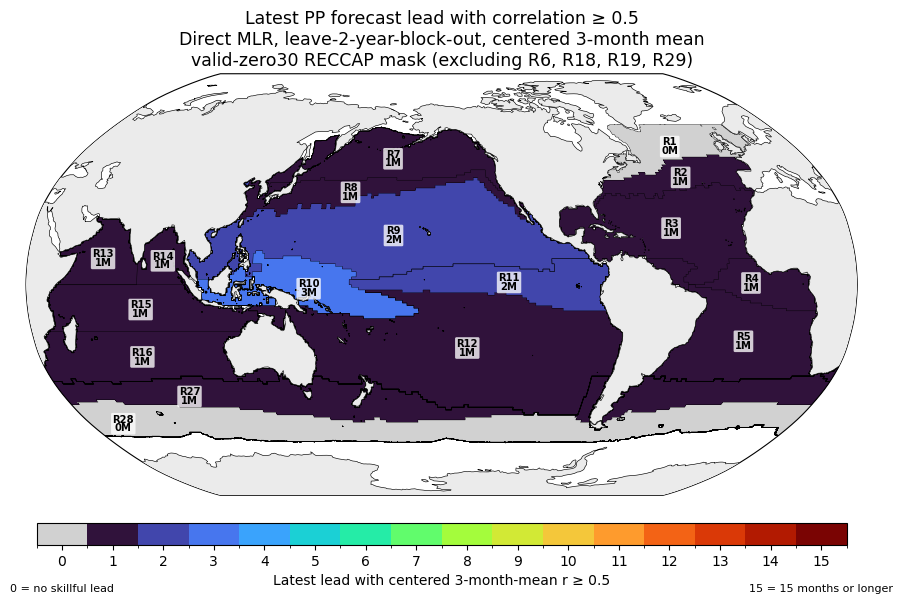

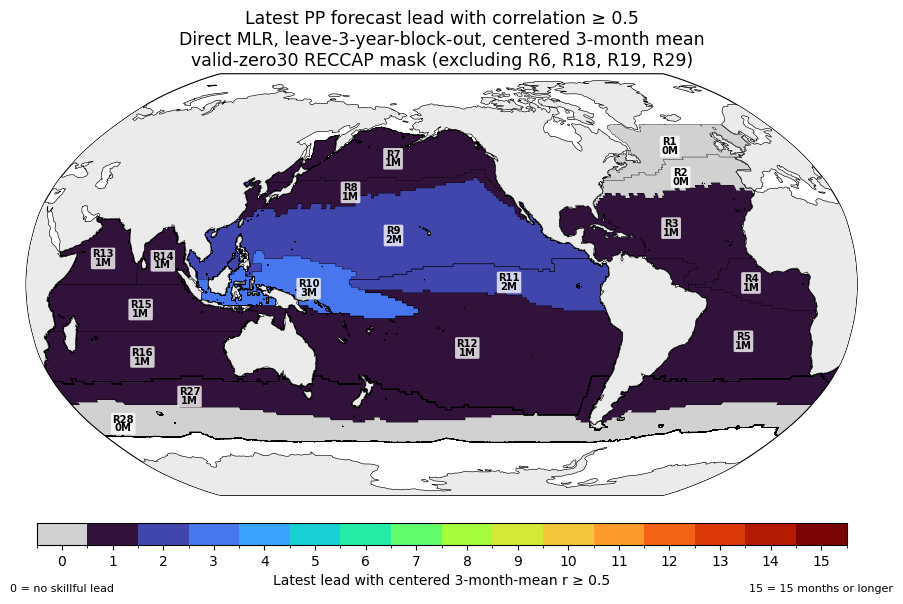

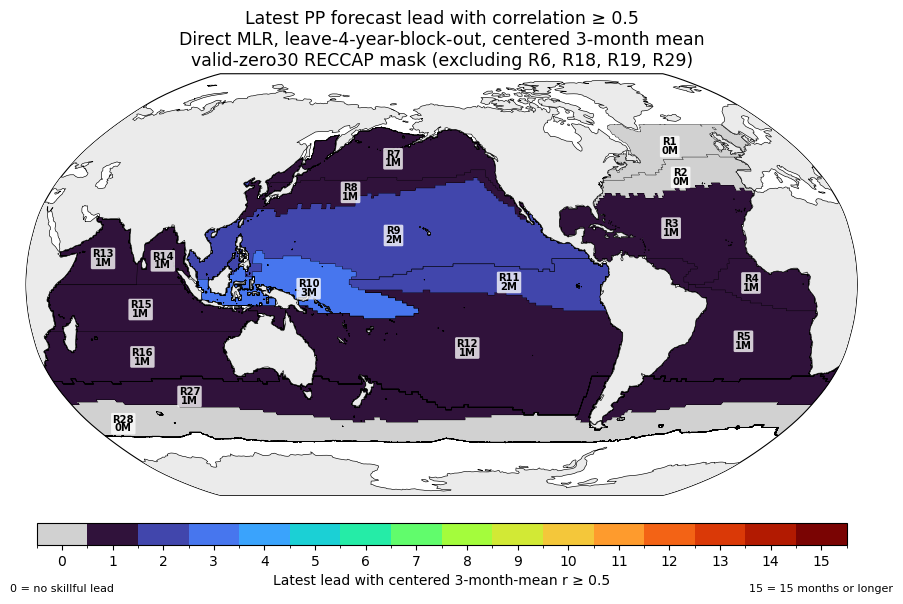

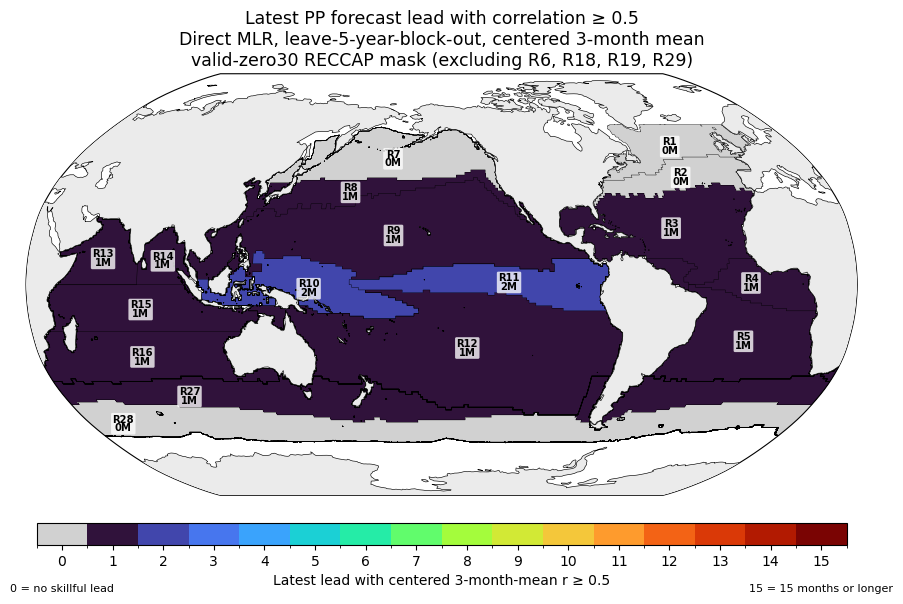

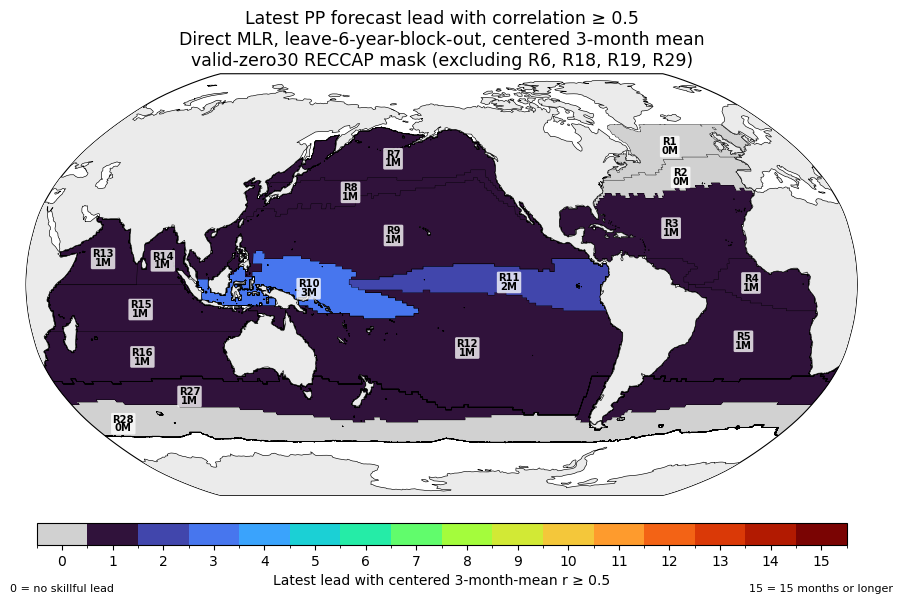

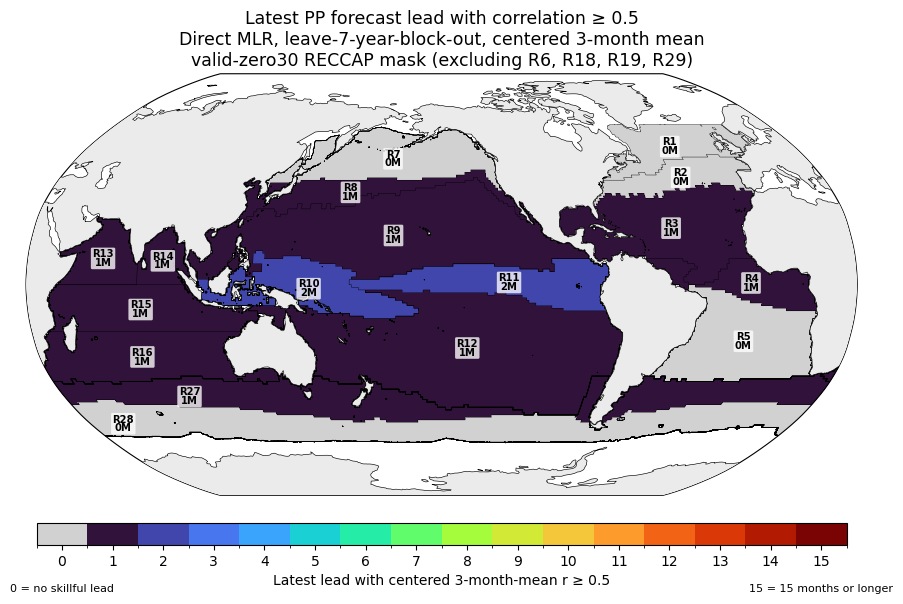

In [6]:

# ============================================================
# 5. Separate latest-skillful-lead map for every window
# ============================================================

import cartopy.crs as ccrs
import cartopy.feature as cfeature

if not VALID_MASK_FILE.exists():
    raise FileNotFoundError(
        f"Mask file not found:\n{VALID_MASK_FILE}"
    )

with xr.open_dataset(VALID_MASK_FILE) as ds:
    ds_mask = ds.load()

mask = ds_mask["valid_region_mask"]
lat = ds_mask.latitude.values.astype(float)
lon = ds_mask.longitude.values.astype(float)
mask_values = mask.values.astype(np.int16)

mask_plot_full = mask_values.copy()
for reg_ex in EXCLUDE_REGIONS:
    mask_plot_full[mask_plot_full == reg_ex] = 0

mask_region_set = set(
    np.unique(
        mask_plot_full[mask_plot_full > 0]
    ).astype(int)
)

remaining_regions = np.unique(
    mask_plot_full[mask_plot_full > 0]
)
boundary_levels = np.arange(
    0.5,
    int(np.nanmax(remaining_regions)) + 1.5,
    1.0,
)

bounds = np.arange(
    -0.5,
    DISPLAY_MAX_LEAD + 1.5,
    1.0,
)
try:
    base = plt.get_cmap(
        "turbo",
        DISPLAY_MAX_LEAD,
    )
except ValueError:
    base = plt.get_cmap(
        "plasma",
        DISPLAY_MAX_LEAD,
    )

colors = (
    [(0.82, 0.82, 0.82, 1.0)]
    + [base(i) for i in range(DISPLAY_MAX_LEAD)]
)
cmap = ListedColormap(colors)
cmap.set_bad((1, 1, 1, 0))
norm = BoundaryNorm(bounds, cmap.N)


for window_years in WINDOW_YEARS:
    window_years = int(window_years)

    if (
        "skill_datasets" in globals()
        and window_years in skill_datasets
    ):
        ds_map_skill = skill_datasets[window_years]
    else:
        with xr.open_dataset(
            skill_file_for_window(window_years)
        ) as ds:
            ds_map_skill = ds.load()

    latest = ds_map_skill["latest_lead_corr_ge_05"]

    regions_to_plot = [
        int(reg)
        for reg in latest.region.values
        if (
            int(reg) not in EXCLUDE_REGIONS
            and int(reg) in mask_region_set
        )
    ]
    latest_plot = latest.sel(region=regions_to_plot)

    lead_map = np.full(
        mask_values.shape,
        np.nan,
        dtype=np.float32,
    )
    for reg in latest_plot.region.values:
        reg = int(reg)
        lead_map[
            mask_plot_full == reg
        ] = float(
            latest_plot.sel(region=reg).values
        )

    lead_map = np.where(
        mask_plot_full > 0,
        lead_map,
        np.nan,
    )

    lat_plot = lat[::PLOT_STRIDE]
    lon_plot = lon[::PLOT_STRIDE]
    lead_plot = lead_map[
        ::PLOT_STRIDE,
        ::PLOT_STRIDE,
    ]
    mask_plot = mask_plot_full[
        ::PLOT_STRIDE,
        ::PLOT_STRIDE,
    ].astype(float)

    lead_cyc, lon_cyc = add_cyclic_manual(
        lead_plot,
        lon_plot,
    )
    mask_cyc, _ = add_cyclic_manual(
        mask_plot,
        lon_plot,
    )

    lead_cyc_plot = np.where(
        np.isfinite(lead_cyc),
        np.minimum(
            lead_cyc,
            DISPLAY_MAX_LEAD,
        ),
        np.nan,
    )

    fig = plt.figure(figsize=(13.5, 6.2))
    ax = plt.axes(
        projection=ccrs.Robinson(
            central_longitude=CENTRAL_LONGITUDE
        )
    )

    im = ax.pcolormesh(
        lon_cyc,
        lat_plot,
        lead_cyc_plot,
        cmap=cmap,
        norm=norm,
        shading="auto",
        transform=ccrs.PlateCarree(),
    )
    ax.contour(
        lon_cyc,
        lat_plot,
        mask_cyc,
        levels=boundary_levels,
        colors="k",
        linewidths=0.30,
        transform=ccrs.PlateCarree(),
    )
    ax.add_feature(
        cfeature.LAND,
        facecolor="0.92",
        edgecolor="none",
        zorder=3,
    )
    ax.coastlines(linewidth=0.45, zorder=4)
    ax.set_global()

    ax.set_title(
        "Latest PP forecast lead with correlation ≥ 0.5\n"
        f"Direct MLR, "
        f"leave-{window_years}-year-block-out, "
        "centered 3-month mean\n"
        "valid-zero30 RECCAP mask "
        "(excluding R6, R18, R19, R29)",
        fontsize=12.5,
    )

    for reg in latest_plot.region.values:
        reg = int(reg)
        region_mask = mask_plot_full == reg
        if not np.any(region_mask):
            continue

        lon_c, lat_c = weighted_centroid(
            lon,
            lat,
            region_mask,
        )
        if not (
            np.isfinite(lon_c)
            and np.isfinite(lat_c)
        ):
            continue

        value = int(
            latest_plot.sel(region=reg).values
        )
        ax.text(
            lon_to_180(lon_c),
            lat_c,
            f"R{reg}\n{value}M",
            transform=ccrs.PlateCarree(),
            ha="center",
            va="center",
            fontsize=7.2,
            fontweight="bold",
            linespacing=0.85,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.78,
                boxstyle="round,pad=0.14",
            ),
            zorder=5,
        )

    fig.subplots_adjust(
        left=0.03,
        right=0.97,
        top=0.84,
        bottom=0.16,
    )
    cax = fig.add_axes(
        [0.20, 0.08, 0.60, 0.035]
    )
    cbar = fig.colorbar(
        im,
        cax=cax,
        orientation="horizontal",
        ticks=np.arange(
            0,
            DISPLAY_MAX_LEAD + 1,
            1,
        ),
        boundaries=bounds,
    )
    cbar.set_label(
        "Latest lead with centered "
        "3-month-mean r ≥ 0.5"
    )
    cbar.ax.text(
        0,
        -1.8,
        "0 = no skillful lead",
        ha="center",
        va="top",
        transform=cbar.ax.get_xaxis_transform(),
        fontsize=8,
    )
    cbar.ax.text(
        DISPLAY_MAX_LEAD,
        -1.8,
        (
            f"{DISPLAY_MAX_LEAD} = "
            f"{DISPLAY_MAX_LEAD} months or longer"
        ),
        ha="center",
        va="top",
        transform=cbar.ax.get_xaxis_transform(),
        fontsize=8,
    )

    if SAVE_FIGURES:
        fig.savefig(
            map_file_for_window(window_years),
            dpi=200,
            bbox_inches="tight",
        )
    plt.show()
